In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense,Dropout,Flatten
from tensorflow.keras.utils import to_categorical

In [3]:
test_data = pd.read_csv("D:\\python-venv\\NN\\data\\fashion-mnist_test.csv")
train_data = pd.read_csv("D:\\python-venv\\NN\\data\\fashion-mnist_train.csv")
test_data = test_data.values
train_data = train_data.values

In [4]:
fashion_mnist = np.concatenate((train_data , test_data) ,  axis=0)

In [5]:
X_train = train_data[: , 1:].reshape(-1,28,28)
X_test = test_data[: , 1:].reshape(-1,28,28)
y_train = train_data[: , 0]
y_test = test_data[: , 0]

In [6]:
class_name = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

Testing our dataset is truely uploaded!

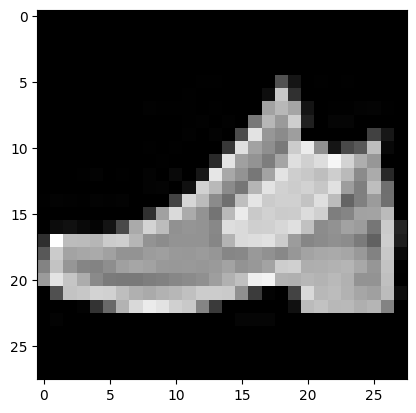

Ankle boot


In [7]:
index=1
plt.imshow(X_train[index],cmap='gray')
plt.show()
print(class_name[y_train[index]])

In [8]:
X_train.shape

(60000, 28, 28)

In [9]:
X_test.shape

(10000, 28, 28)

In [10]:
y_train.shape

(60000,)

In [11]:
y_test.shape

(10000,)

In [12]:
y_test = to_categorical(y_test)
y_train = to_categorical(y_train)

In [13]:
y_train[0]

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])

In [14]:
X_train = train_data[: , 1:].reshape(-1,28*28)
X_test = test_data[: , 1:].reshape(-1,28*28)

Normalizing.

In [15]:
X_train = X_train / 255
X_test = X_test / 255

Model

In [16]:
model = keras.models.Sequential()
model.add(Flatten(input_shape=(784,)))
model.add(Dense(units=365 , activation='relu' ))
model.add(Dropout(0.5))
model.add(Dense(units=256 , activation='relu' ))
model.add(Dropout(0.4))
model.add(Dense(units=10 , activation='softmax'))

d:\python-venv\keras2\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 365)            │       286,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 365)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        93,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 382,791 (1.46 MB)

 Trainable params: 382,791 (1.46 MB)

 Non-trainable params: 0 (0.00 B)

Using true kind of optimizer and loss functions and metric that is suitable with our work,

In [18]:
opt = tf.optimizers.Adam(learning_rate=0.001)
loss = tf.losses.CategoricalCrossentropy()

model.compile(optimizer=opt , loss= loss , metrics= [tf.metrics.CategoricalAccuracy()])

Fitting the models and saving epoch and loss on a history for visualizing the loss per epoch for best epoch setting.

In [20]:
history = model.fit(X_train, y_train, epochs=40, batch_size=100, validation_split=0.25, verbose=2)

Epoch 1/40
450/450 - 3s - 6ms/step - categorical_accuracy: 0.7550 - loss: 0.6759 - val_categorical_accuracy: 0.8379 - val_loss: 0.4576
Epoch 2/40
450/450 - 2s - 4ms/step - categorical_accuracy: 0.8208 - loss: 0.4892 - val_categorical_accuracy: 0.8528 - val_loss: 0.3985
Epoch 3/40
450/450 - 2s - 4ms/step - categorical_accuracy: 0.8333 - loss: 0.4483 - val_categorical_accuracy: 0.8636 - val_loss: 0.3809
Epoch 4/40
450/450 - 2s - 5ms/step - categorical_accuracy: 0.8459 - loss: 0.4229 - val_categorical_accuracy: 0.8634 - val_loss: 0.3713
Epoch 5/40
450/450 - 2s - 5ms/step - categorical_accuracy: 0.8513 - loss: 0.4082 - val_categorical_accuracy: 0.8669 - val_loss: 0.3746
Epoch 6/40
450/450 - 3s - 6ms/step - categorical_accuracy: 0.8569 - loss: 0.3953 - val_categorical_accuracy: 0.8754 - val_loss: 0.3518
Epoch 7/40
450/450 - 2s - 5ms/step - categorical_accuracy: 0.8588 - loss: 0.3837 - val_categorical_accuracy: 0.8762 - val_loss: 0.3508
Epoch 8/40
450/450 - 2s - 5ms/step - categorical_accura

In [21]:
model.evaluate(X_test , y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - categorical_accuracy: 0.8900 - loss: 0.3053


[0.30525925755500793, 0.8899999856948853]

In [22]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

Visualizing the loss per epoch.

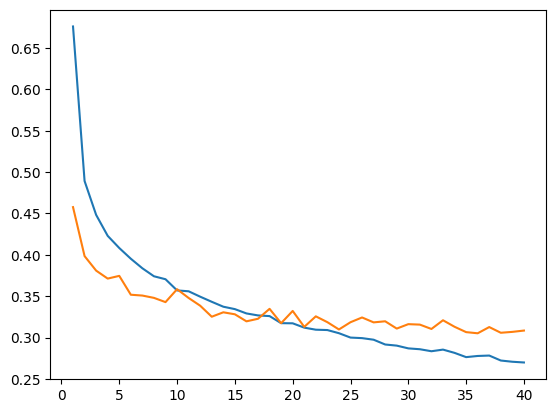

In [23]:
plt.plot(epochs , loss)
plt.plot(epochs , val_loss)
plt.show()